In [1]:
import pandas as pd

dados = [
["2026-01-01","Lazer","despesa",120.50],
["2026-01-02","Transporte","despesa",15.20],
["2026-01-03","Alimentacao","despesa",45.00],
["2026-01-04","Saude","despesa",80.00],
["2026-01-05","Lazer","despesa",60.00],
["2026-01-06","Transporte","despesa",20.00],
["2026-01-07","Alimentacao","despesa",30.00],
["2026-01-08","Lazer","despesa",150.00],
["2026-01-09","Saude","despesa",70.00],
["2026-01-10","Transporte","despesa",25.00],

["2026-02-01","Alimentacao","despesa",55.00],
["2026-02-02","Lazer","despesa",200.00],
["2026-02-03","Transporte","despesa",18.00],
["2026-02-04","Saude","despesa",90.00],
["2026-02-05","Alimentacao","despesa",35.00],
["2026-02-06","Lazer","despesa",130.00],
["2026-02-07","Transporte","despesa",22.00],
["2026-02-08","Alimentacao","despesa",40.00],
["2026-02-09","Saude","despesa",65.00],
["2026-02-10","Lazer","despesa",170.00],

["2026-03-01","Transporte","despesa",30.00],
["2026-03-02","Alimentacao","despesa",60.00],
["2026-03-03","Lazer","despesa",210.00],
["2026-03-04","Saude","despesa",95.00],
["2026-03-05","Alimentacao","despesa",50.00],
["2026-03-06","Transporte","despesa",28.00],
["2026-03-07","Lazer","despesa",180.00],
["2026-03-08","Saude","despesa",75.00],
["2026-03-09","Alimentacao","despesa",45.00],
["2026-03-10","Transporte","despesa",20.00]
]

df = pd.DataFrame(dados, columns=["data","categoria","tipo","valor"])

df.to_csv("gastos_pessoais.csv", index=False)

df.head()

,data,categoria,tipo,valor
0,2026-01-01,Lazer,despesa,120.5
1,2026-01-02,Transporte,despesa,15.2
2,2026-01-03,Alimentacao,despesa,45.0
3,2026-01-04,Saude,despesa,80.0
4,2026-01-05,Lazer,despesa,60.0


Total gasto: 2233.7

Gastos por categoria:
categoria
Alimentacao     360.0
Lazer          1220.5
Saude           475.0
Transporte      178.2
Name: valor, dtype: float64


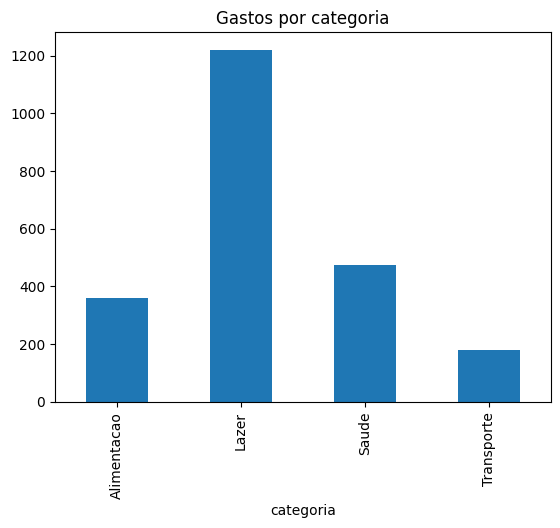


Erro médio: 25.488985270049103


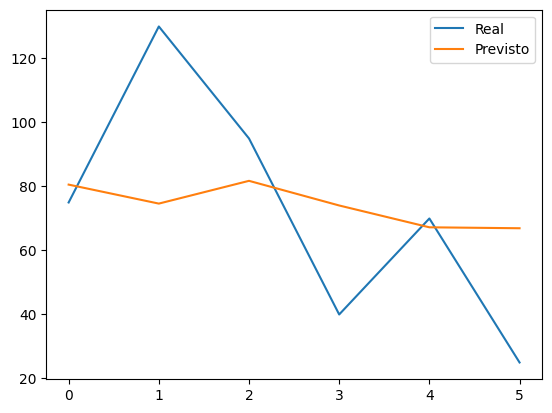

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# usar o dataset que você já criou
df = pd.read_csv("gastos_pessoais.csv")

# =========================
# TRATAMENTO
# =========================
df["data"] = pd.to_datetime(df["data"])
df["mes"] = df["data"].dt.month
df["dia"] = df["data"].dt.day

# =========================
# ANÁLISE
# =========================
print("Total gasto:", df["valor"].sum())

print("\nGastos por categoria:")
print(df.groupby("categoria")["valor"].sum())

# gráfico
df.groupby("categoria")["valor"].sum().plot(kind="bar")
plt.title("Gastos por categoria")
plt.show()

# =========================
# MACHINE LEARNING
# =========================
X = df[["dia", "mes"]]
y = df["valor"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

previsoes = modelo.predict(X_test)

# =========================
# RESULTADO
# =========================
erro = mean_absolute_error(y_test, previsoes)

print("\nErro médio:", erro)

# gráfico final
plt.plot(y_test.values, label="Real")
plt.plot(previsoes, label="Previsto")
plt.legend()
plt.show()